In [28]:
#environment setup
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch.nn as nn
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split

In [29]:
#load all the csv files
users = pd.read_csv('users.csv')
events = pd.read_csv('ad_events.csv')
campaigns = pd.read_csv('campaigns.csv')
ads = pd.read_csv('ads.csv')

print(f"Events: {len(events):,}")
print(events['event_type'].value_counts())

Events: 400,000
event_type
Impression    339812
Click          40079
Like           12013
Comment         4108
Purchase        2031
Share           1957
Name: count, dtype: int64


In [30]:
from pandas.core import groupby
#engagement score
weights = {
    'Impression': 0,
    'Click': 1,
    'Like': 2,
    'Comment': 2,
    'Share': 3,
    'Purchase': 5,
}

events['engagement_weight'] = events['event_type'].map(weights)

#group actions by user and ad ids (one user can have multiple interaction with one ad)
engagement = (events
    .groupby(['ad_id', 'user_id'])['engagement_weight'].sum().reset_index().rename(columns = {'engagement_weight': 'engagement_score'})
)

print(engagement.shape)
print(engagement['engagement_score'].describe())



(362122, 3)
count    362122.000000
mean          0.243970
std           0.653865
min           0.000000
25%           0.000000
50%           0.000000
75%           0.000000
max           9.000000
Name: engagement_score, dtype: float64


In [31]:
#merge engagements with ads
df = engagement.merge(ads, on = 'ad_id')

#merge engagements with campaigns
df = df.merge(campaigns[['campaign_id', 'total_budget', 'duration_days']], on = 'campaign_id')

#merge with user info
df = df.merge(users[['user_id', 'user_age', 'user_gender']], on = 'user_id')

print(df.shape)
print(df.head())

(365390, 13)
   ad_id user_id  engagement_score  campaign_id ad_platform ad_type  \
0      1   00067                 0           28    Facebook   Video   
1      1   0023e                 0           28    Facebook   Video   
2      1   00336                 0           28    Facebook   Video   
3      1   004a5                 0           28    Facebook   Video   
4      1   00b03                 0           28    Facebook   Video   

  target_gender target_age_group target_interests  total_budget  \
0        Female            35-44  art, technology      32844.79   
1        Female            35-44  art, technology      32844.79   
2        Female            35-44  art, technology      32844.79   
3        Female            35-44  art, technology      32844.79   
4        Female            35-44  art, technology      32844.79   

   duration_days  user_age user_gender  
0             52        38        Male  
1             52        35      Female  
2             52        25      Fe

In [32]:
#encode categoricals
le = LabelEncoder()

#converting strings into numbers
cat_cols = ['ad_platform', 'ad_type', 'target_gender', 'target_age_group', 'user_gender']

for col in cat_cols:
  df[col] = le.fit_transform(df[col].astype(str))

print(df[cat_cols].head())

   ad_platform  ad_type  target_gender  target_age_group  user_gender
0            0        3              1                 2            1
1            0        3              1                 2            0
2            0        3              1                 2            0
3            0        3              1                 2            1
4            0        3              1                 2            0


In [33]:
feature_cols = [
    'user_age', 'user_gender', 'ad_platform', 'ad_type', 'target_gender', 'total_budget', 'duration_days'
]

x = df_engaged[feature_cols].values
y= df_engaged['engagement_score'].values.reshape(-1,1)

#Log-transform
y = np.log1p(y)

#scale
scaler_x = StandardScaler()
#scaler_y = StandardScaler() - Now y is already log-compressed

x = scaler_x.fit_transform(x)
#y = scaler_y.fit_transform(y)

print(f"X Shape: {x.shape}, Y Shape: {y.shape}")
print(f"y range: {y.min():.3f} to {y.max():.3f}")

X Shape: (59968, 7), Y Shape: (59968, 1)
y range: 0.693 to 2.303


In [34]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.2, random_state = 42)

#convert to tensors
x_train = torch.FloatTensor(x_train)
x_test = torch.FloatTensor(x_test)
y_train = torch.FloatTensor(y_train)
y_test = torch.FloatTensor(y_test)

print(f"Train: {x_train.shape}, Test: {x_test.shape}")

Train: torch.Size([47974, 7]), Test: torch.Size([11994, 7])


In [35]:
#building the model
class AdEngagementScore(nn.Module):
  def __init__(self, input_size):
    super().__init__()
    self.network = nn.Sequential(
        nn.Linear(input_size, 64),
        nn.ReLU(),
        nn.Dropout(0.2), #Randomly turns off 20% of neurons
        nn.Linear(64, 32),
        nn.ReLU(),
        nn.Dropout(0.2),
        nn.Linear(32,16),
        nn.ReLU(),
        nn.Linear(16,1)
    )
  #forward pass
  def forward(self,x):
    return self.network(x)

model = AdEngagementScore(input_size = len(feature_cols))
print(model)

AdEngagementScore(
  (network): Sequential(
    (0): Linear(in_features=7, out_features=64, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.2, inplace=False)
    (3): Linear(in_features=64, out_features=32, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.2, inplace=False)
    (6): Linear(in_features=32, out_features=16, bias=True)
    (7): ReLU()
    (8): Linear(in_features=16, out_features=1, bias=True)
  )
)


In [36]:
#Train the model
loss_fn = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr = 0.0005) #lower learning rate than before (0.001)

epochs = 300 #increased epochs
train_losses, test_losses = [], []

for epoch in range(epochs):
  model.train()
  preds = model(x_train)
  loss  = loss_fn(preds, y_train)

  optimizer.zero_grad()
  loss.backward()
  optimizer.step()

  model.eval()
  with torch.no_grad():
    test_preds = model(x_test)
    test_loss = loss_fn(test_preds, y_test)

  train_losses.append(loss.item())
  test_losses.append(test_loss.item())

  if epoch%20 == 0:
    print(f"Epoch: {epoch:3d} | Train: {loss.item():.4f} | Test: {test_loss.item():.4f}")

Epoch:   0 | Train: 0.5045 | Test: 0.4911
Epoch:  20 | Train: 0.2557 | Test: 0.2441
Epoch:  40 | Train: 0.1121 | Test: 0.0982
Epoch:  60 | Train: 0.1005 | Test: 0.0844
Epoch:  80 | Train: 0.0944 | Test: 0.0818
Epoch: 100 | Train: 0.0932 | Test: 0.0799
Epoch: 120 | Train: 0.0914 | Test: 0.0795
Epoch: 140 | Train: 0.0904 | Test: 0.0791
Epoch: 160 | Train: 0.0896 | Test: 0.0788
Epoch: 180 | Train: 0.0887 | Test: 0.0784
Epoch: 200 | Train: 0.0880 | Test: 0.0782
Epoch: 220 | Train: 0.0874 | Test: 0.0779
Epoch: 240 | Train: 0.0864 | Test: 0.0776
Epoch: 260 | Train: 0.0858 | Test: 0.0773
Epoch: 280 | Train: 0.0851 | Test: 0.0770


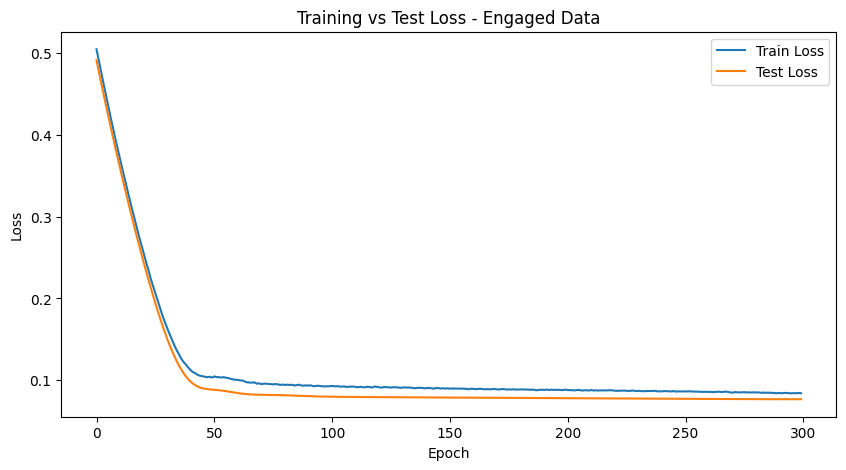

Final Train Loss: 0.0842
Final Test Loss: 0.076893


In [37]:
#plotting a graph
plt.figure(figsize = (10, 5))
plt.plot(train_losses, label = "Train Loss")
plt.plot(test_losses, label = "Test Loss")
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training vs Test Loss - Engaged Data') #New only engaged users
plt.legend()
plt.show()

print(f"Final Train Loss: {train_losses[-1]:.4f}")
print(f"Final Test Loss: {test_losses[-1]:4f}")

count    365390.000000
mean          0.244268
std           0.654211
min           0.000000
25%           0.000000
50%           0.000000
75%           0.000000
max           9.000000
Name: engagement_score, dtype: float64

engagement_score
0    305422
1     39363
2     16207
3      2244
5      2021
4        90
6        27
7        12
8         3
9         1
Name: count, dtype: int64


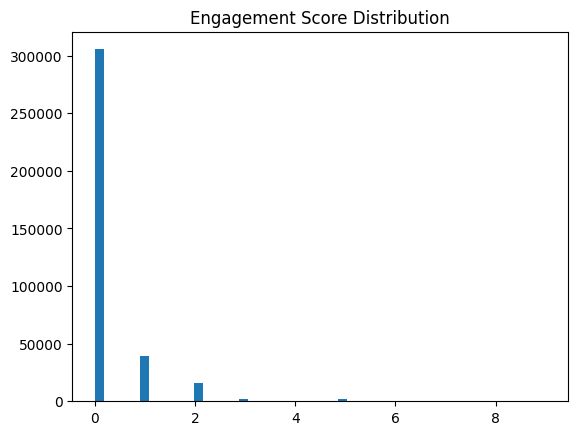

In [38]:
#Finding the problem
print(df['engagement_score'].describe())
print()
print(df['engagement_score'].value_counts().head(10))

plt.hist(df['engagement_score'], bins = 50)
plt.title('Engagement Score Distribution')
plt.show()

Original rows: 365,390
New rows: 59,968
Kept: 16.4%

count    59968.000000
mean         1.488344
std          0.869586
min          1.000000
25%          1.000000
50%          1.000000
75%          2.000000
max          9.000000
Name: engagement_score, dtype: float64


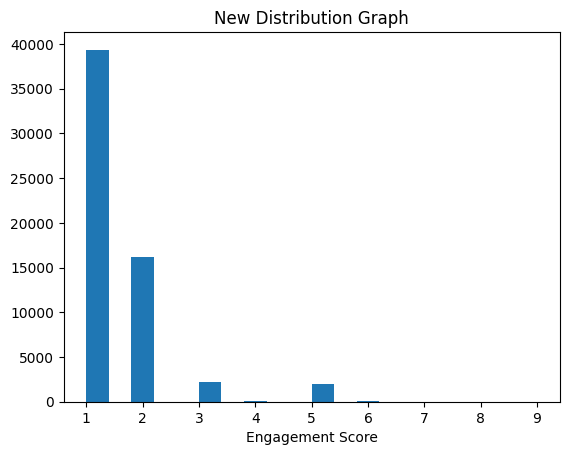

In [39]:
#Filtering to engaged rows
df_engaged = df[df['engagement_score'] > 0].copy()

print(f"Original rows: {len(df):,}")
print(f"New rows: {len(df_engaged):,}")
print(f"Kept: {len(df_engaged)/len(df)*100:.1f}%")
print()
print(df_engaged['engagement_score'].describe())

plt.hist(df_engaged['engagement_score'], bins = 20)
plt.title('New Distribution Graph')
plt.xlabel('Engagement Score')
plt.show()

EDA Summary
1. Built Engagement Score from the event weights ( Impressions: 0, Clicks: 1, Comments: 2, Likes: 2, Shares: 3, Purchases: 5 )
2. Fixed the Imbalance as in the initial Loss Curve, the model was not learning, so the learning was lowered from 0.001 to 0.0005 and added dropout to prevent memorisation on smaller dataset.
3. Log Transformed the output to compress skewed distribution